In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd "/content/drive/MyDrive/Master's Thesis/TM Project/"

/content/drive/MyDrive/Master's Thesis/TM Project


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
# !pip install scikit-optimize

In [5]:
# from skopt import gp_minimize
# from skopt import space

In [6]:
import devices
import models
import samplers
import trainers
import utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

from scipy.io import loadmat

In [7]:
# parameters
lambd = 1

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd

# device 3 is done for both scalar and TM
# device 3
#spacing
dx = (0.0976/1.55) * k_0
dy =  (0.1/1.55) * k_0

# simulation lengths

core_length_x = ((4/1.55) * lambd) * k_0 # W
core_length_y = ((2.5/1.55) * lambd) * k_0 # H

substrate_length_x = ((4.34/1.55) * lambd) * k_0 # Xs
substrate_length_y = ((7.550/1.55) * lambd) * k_0 # Ys

rib_length = ((3.5/1.55) * lambd) * k_0 # D

cladding_length_y = ((0.55/1.55) * lambd) * k_0 # Yc

# refractive indices
n_core = 3.44
n_substrate = 3.435
n_cladding = 1

In [8]:
study = 'scalar'

In [9]:
memory_type = torch.device('cuda')
dtype = torch.float32
torch.manual_seed(42)
num_modes = 1

In [10]:
reference_device = devices.RibWaveguide(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study)

In [11]:
xy = samplers.uniform_grid_2d(reference_device, dx, dy, dtype, memory_type)
xy = xy.cpu()

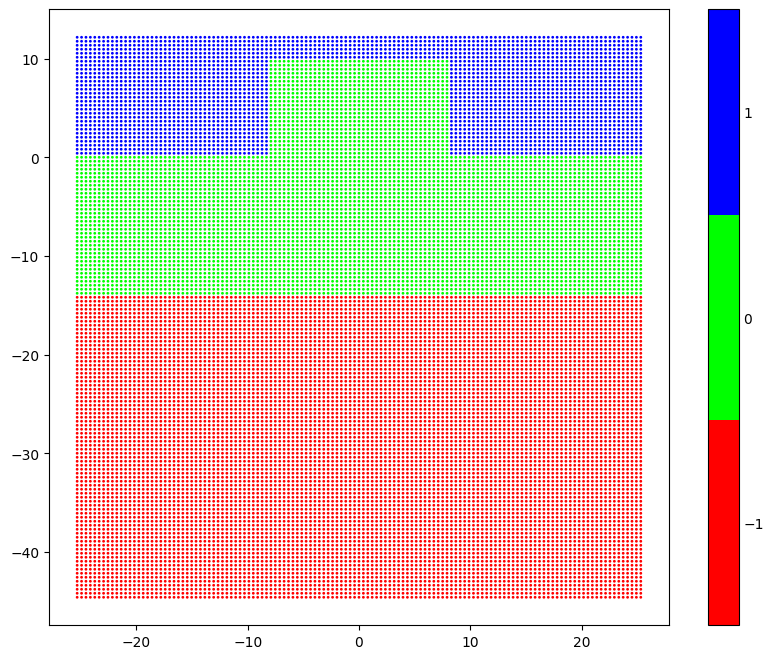

In [12]:
plt.figure(figsize=(10, 8))

from_list = matplotlib.colors.LinearSegmentedColormap.from_list
cm = from_list(None, [(1, 0, 0), (0, 1, 0), (0, 0, 1)], 3)
plt.scatter(xy[:, 0], xy[:, 1], s=1, c=reference_device.regions(xy, format='torch'), cmap=cm);
plt.clim(-1.5, 1.5)
cb = plt.colorbar(ticks=[-1, 0, 1])
cb.ax.tick_params(length=0)

In [13]:
boudndary_pts, boundary_vals = reference_device.get_boundaries(xy.detach().clone(), dx, dy, dtype,  memory_type)

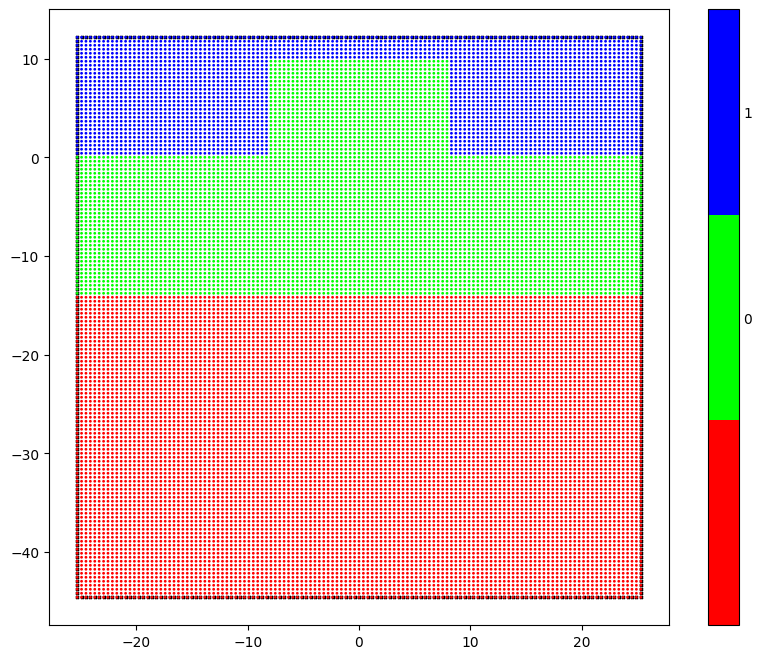

In [14]:
plt.figure(figsize=(10, 8))

from_list = matplotlib.colors.LinearSegmentedColormap.from_list
cm = from_list(None, [(1, 0, 0), (0, 1, 0), (0, 0, 1)], 3)
plt.scatter(boudndary_pts[:, 0], boudndary_pts[:, 1], marker='x', s=4, c='black');
plt.scatter(xy[:, 0], xy[:, 1], s=1, c=reference_device.regions(xy, format='torch'), cmap=cm);
plt.clim(-1.5, 1.5)
cb = plt.colorbar(ticks=[0, 1])
cb.ax.tick_params(length=0)

In [15]:
discontinuities = reference_device.get_discontinuities(xy.detach().clone(), dx, dy)

<ipython-input-16-8c52820d3a78>:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(boudndary_pts[:, 0], boudndary_pts[:, 1], marker='x', s=4, c='black', cmap=cm);
<ipython-input-16-8c52820d3a78>:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(discontinuity[:, 0].detach(), discontinuity[:, 1].detach(), s=1/2, marker='x', c='orange', cmap=cm);


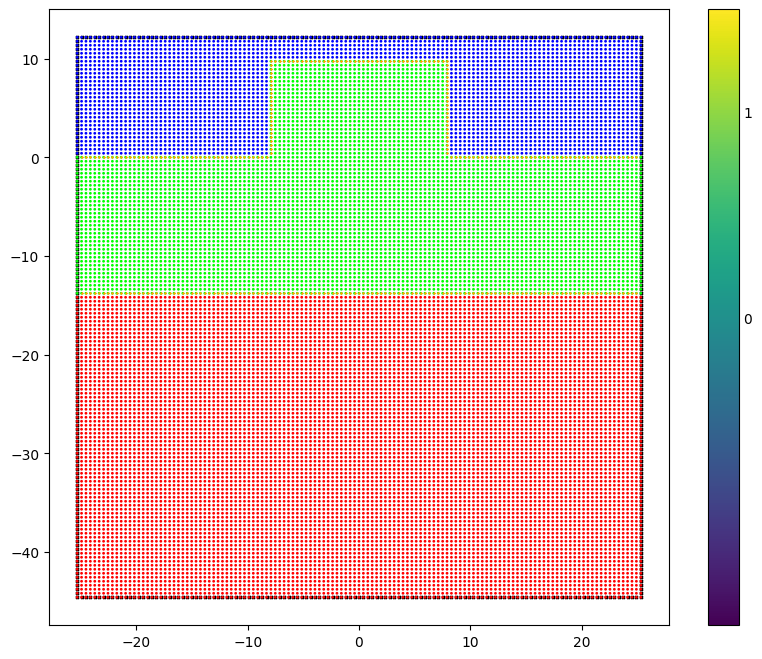

In [16]:
plt.figure(figsize=(10, 8))

from_list = matplotlib.colors.LinearSegmentedColormap.from_list
cm = from_list(None, [(1, 0, 0), (0, 1, 0), (0, 0, 1)], 3)
plt.scatter(boudndary_pts[:, 0], boudndary_pts[:, 1], marker='x', s=4, c='black', cmap=cm);

plt.scatter(xy[:, 0], xy[:, 1], s=1, c=reference_device.regions(xy, format='torch'), cmap=cm);

for discontinuity in discontinuities:
  plt.scatter(discontinuity[:, 0].detach(), discontinuity[:, 1].detach(), s=1/2, marker='x', c='orange', cmap=cm);

# len_rib = guide.lengths_y[1]
# len_rib = ((guide.lengths_y[1])//dy)*dy

# plt.axhline(y=-len_rib, color='black', linestyle='dashed')
plt.clim(-1.5, 1.5)
cb = plt.colorbar(ticks=[0, 1])
cb.ax.tick_params(length=0)

In [17]:
study = 'scalar'

In [18]:
memory_type = torch.device('cuda')
dtype = torch.float32
torch.manual_seed(42)
num_modes = 1

In [19]:
# base_model = models.discontinuity_capturing_network(2, 256, num_modes, 1, 'RBF')
base_model = models.discontinuity_capturing_network(2, 512, num_modes, 1, 'RBF')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
# optimizer = torch.optim.LBFGS(base_model.parameters(),
#                               lr=float(5e-1),
#                               max_iter=5000,
#                               max_eval=5000,
#                               history_size=300,
#                               line_search_fn="strong_wolfe",
#                               tolerance_change=10.0 * np.finfo(float).eps)
# scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[1000, 2000, 3000], gamma=0.2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[3000, 4000], gamma=0.2)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 3073


In [20]:
device = devices.RibWaveguideWithPINNs(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, base_model, True)

In [21]:
train_agent = trainers.Trainer2D(dtype, device, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=None, n_upper=None)

num samples 18189


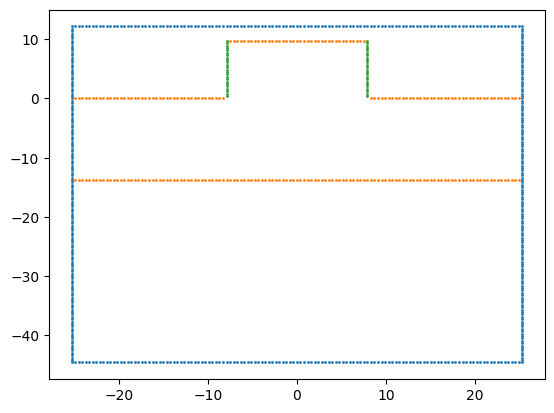

iteration 1 loss1 is 0.2655, loss2 is 0.9913, loss3 is 22.89991, loss4 is 0.0, loss5 is 0.08129, loss6 is 0.20197
3.139692544937134


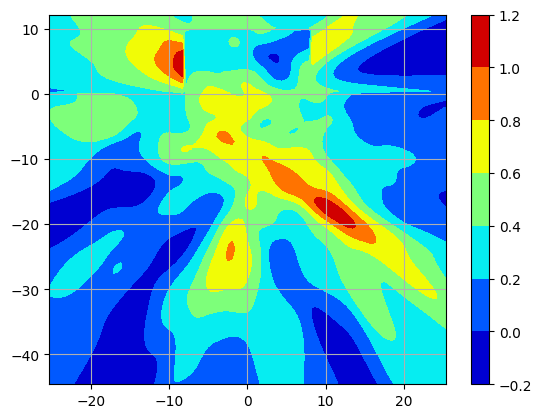

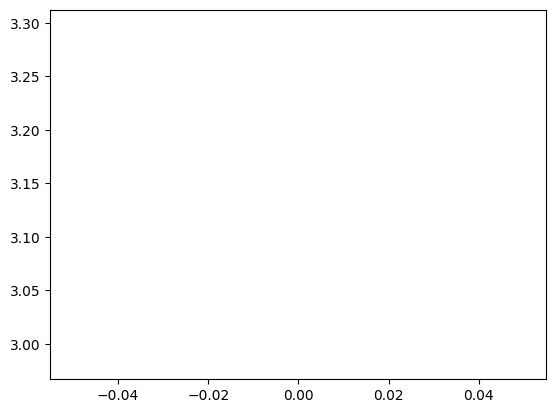

iteration 1001 loss1 is 0.04933, loss2 is 0.01457, loss3 is 0.63246, loss4 is 0.0, loss5 is 0.01384, loss6 is 0.06257
3.4364535808563232


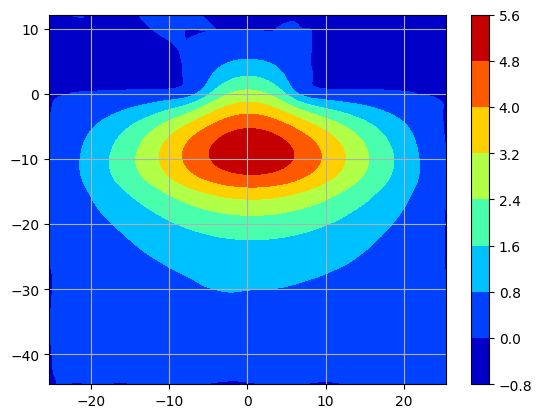

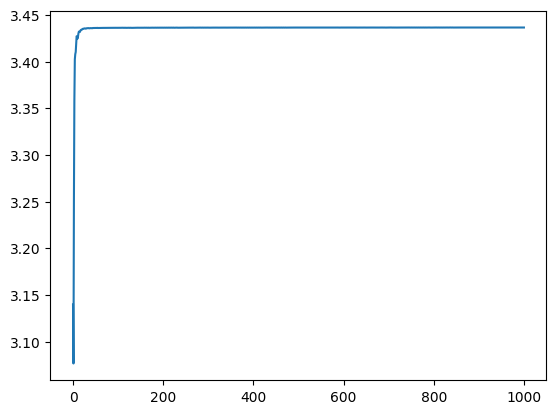

iteration 2001 loss1 is 0.03678, loss2 is 0.00967, loss3 is 0.62399, loss4 is 0.0, loss5 is 0.01182, loss6 is 0.05156
3.436507225036621


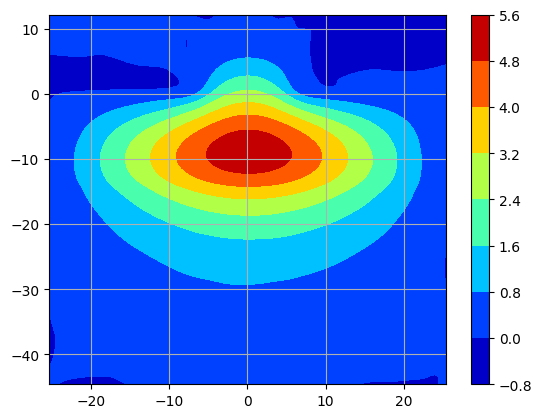

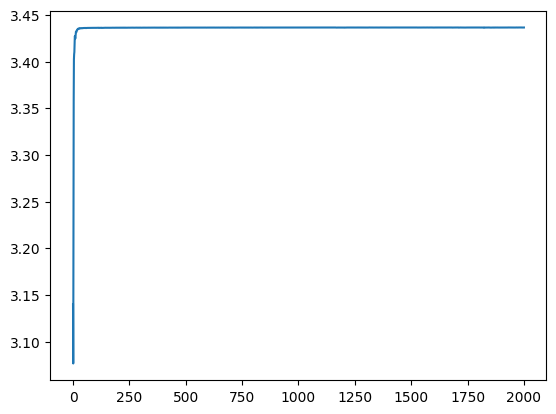

iteration 3001 loss1 is 0.03305, loss2 is 0.00762, loss3 is 0.62119, loss4 is 0.0, loss5 is 0.01187, loss6 is 0.0471
3.436525344848633


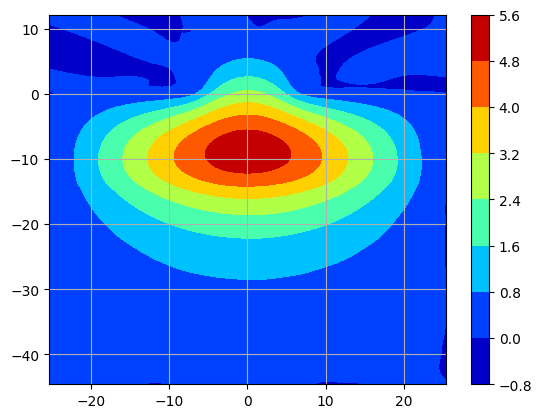

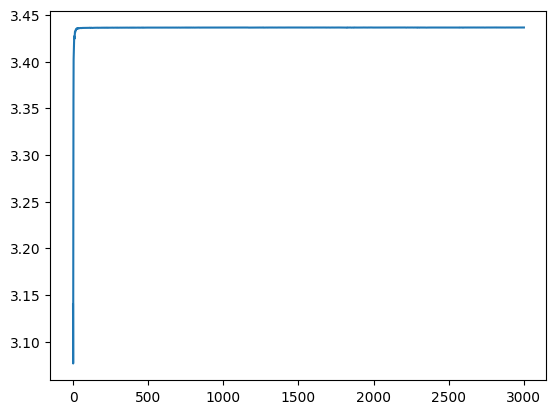

iteration 4001 loss1 is 0.01457, loss2 is 0.00221, loss3 is 0.61929, loss4 is 0.0, loss5 is 0.00226, loss6 is 0.01623
3.436537742614746


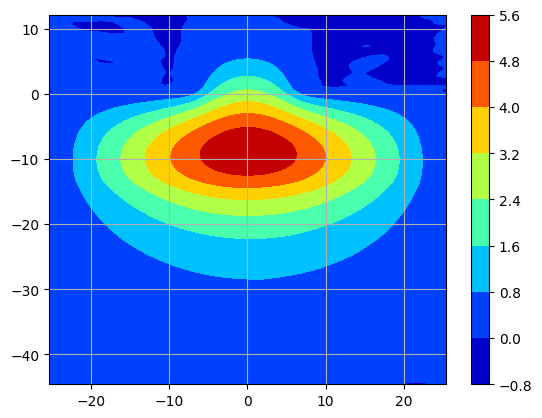

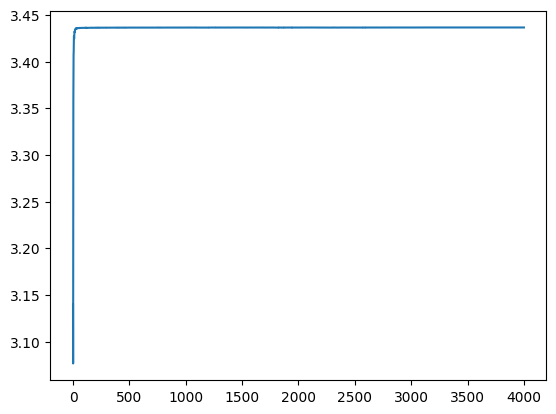

iteration 5001 loss1 is 0.0104, loss2 is 0.00167, loss3 is 0.61901, loss4 is 0.0, loss5 is 0.00086, loss6 is 0.00842
3.436539649963379


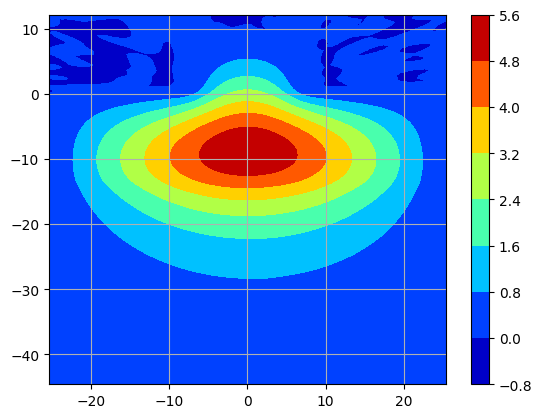

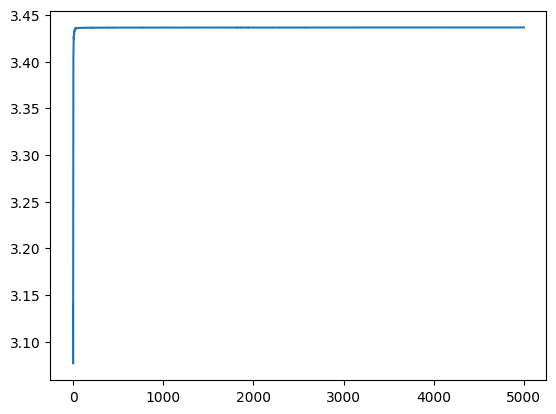

iteration 6001 loss1 is 0.01036, loss2 is 0.00148, loss3 is 0.6192, loss4 is 0.0, loss5 is 0.00074, loss6 is 0.00871
3.4365382194519043


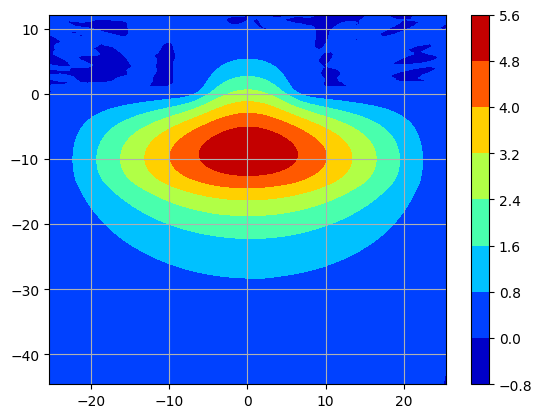

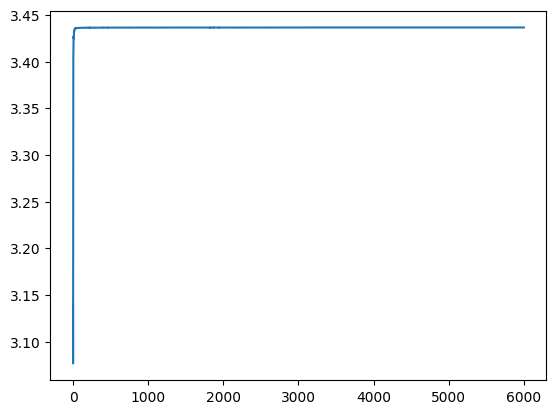

iteration 7001 loss1 is 0.01007, loss2 is 0.00139, loss3 is 0.61915, loss4 is 0.0, loss5 is 0.00072, loss6 is 0.00939
3.4365384578704834


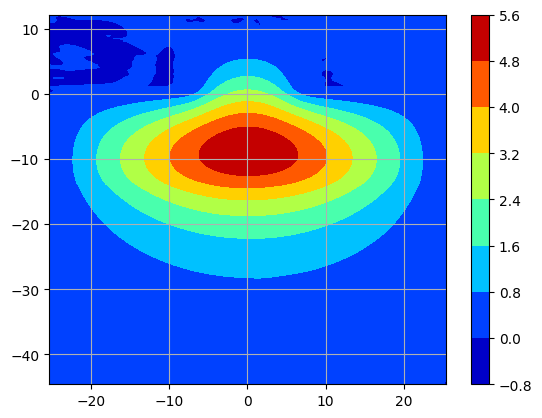

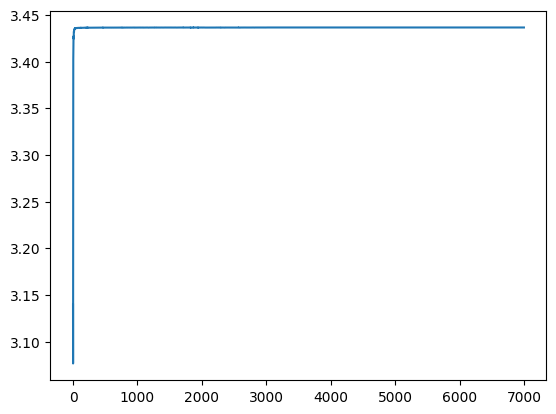

iteration 8001 loss1 is 0.00997, loss2 is 0.0013, loss3 is 0.61915, loss4 is 0.0, loss5 is 0.00078, loss6 is 0.00897
3.4365384578704834


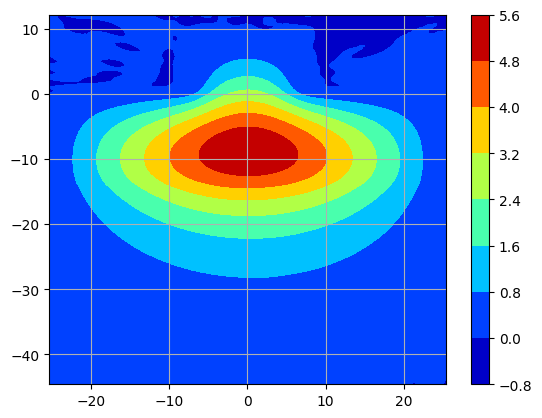

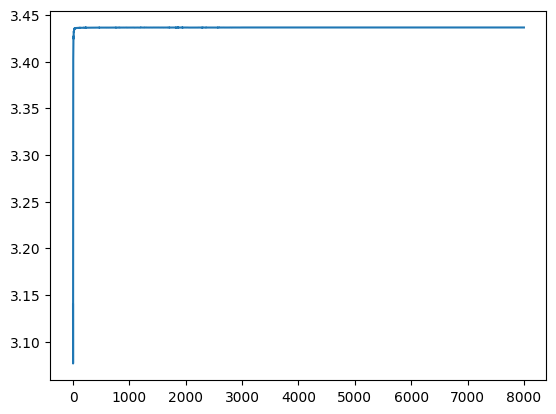

iteration 9001 loss1 is 0.00968, loss2 is 0.00124, loss3 is 0.61906, loss4 is 0.0, loss5 is 0.00074, loss6 is 0.00846
3.4365391731262207


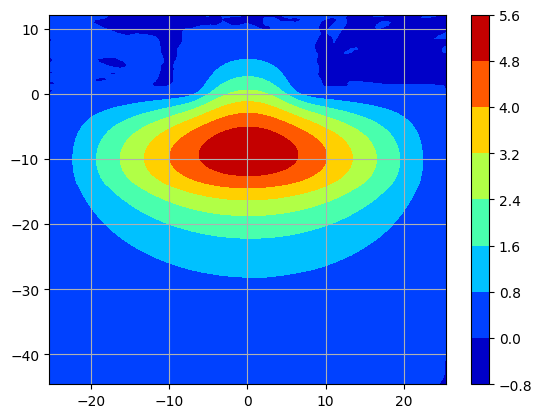

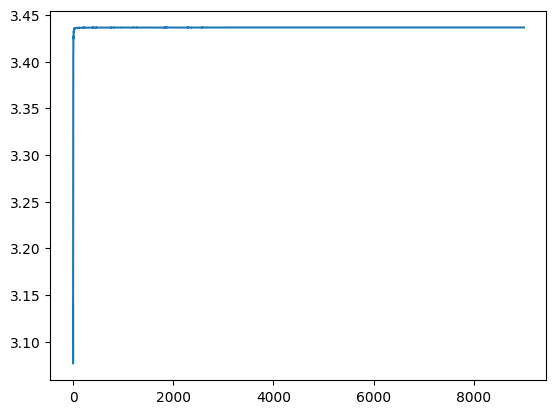

iteration 10001 loss1 is 0.00982, loss2 is 0.00121, loss3 is 0.61901, loss4 is 0.0, loss5 is 0.0007, loss6 is 0.00913
3.436539649963379


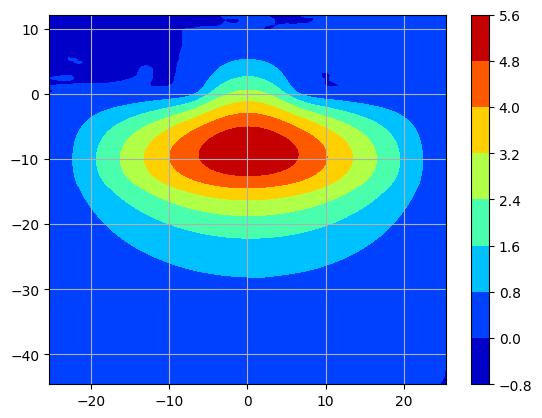

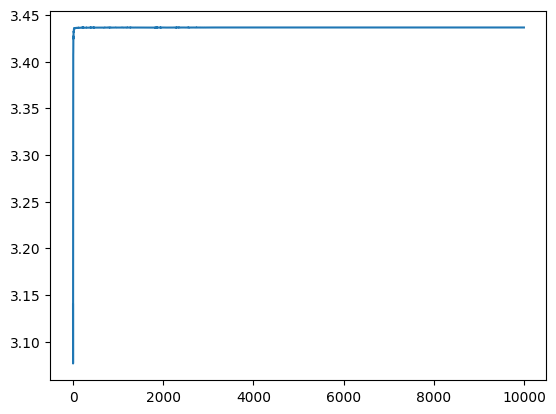

In [22]:
# loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[1, 1, 1, 1, 1, 1], verbose=1, sample_new=False)
loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[5, 1/2, 1/2, 1/2, 1, 1], verbose=1, calc_error=False, plot_solution=True, sample_new=False)

In [23]:
base_model.to('cpu')

Sequential(
  (0): Linear(in_features=3, out_features=512, bias=True)
  (1): RBF()
  (2): Linear(in_features=512, out_features=1, bias=True)
)

In [24]:
yu = torch.arange(0, reference_device.upward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yu = yu[-1]
yb = torch.arange(0, reference_device.downward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yb = yb[-1]
xy = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))

xy = torch.cat((torch.full_like(xy, 0), xy), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy, torch.square(reference_device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

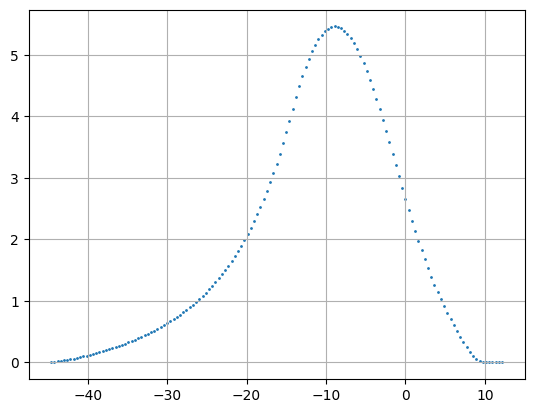

In [25]:
plt.scatter(xy[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [26]:
xy = torch.arange(-device.total_length_x/2, device.total_length_x/2, step=dx/2, device=memory_type).reshape(-1, 1)
xy = torch.cat((xy, torch.full_like(xy, 0)), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy[:], torch.square(device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

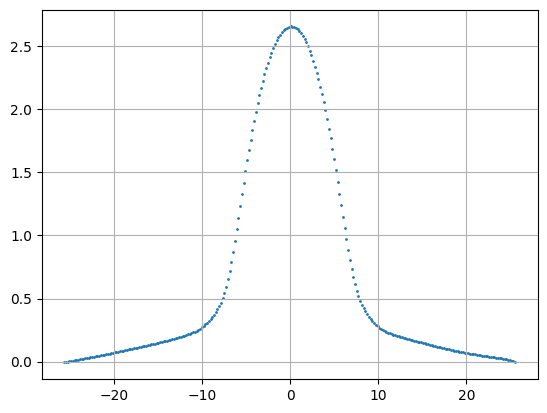

In [27]:
plt.scatter(xy[:, 0].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [28]:
study = 'TE'

In [29]:
memory_type = torch.device('cuda')
dtype = torch.float32
torch.manual_seed(42)
num_modes = 1

In [30]:
# base_model = models.discontinuity_capturing_network(2, 256, num_modes, 1, 'RBF')
base_model = models.discontinuity_capturing_network(2, 512, num_modes, 1, 'RBF')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
# optimizer = torch.optim.LBFGS(base_model.parameters(),
#                               lr=float(5e-1),
#                               max_iter=5000,
#                               max_eval=5000,
#                               history_size=300,
#                               line_search_fn="strong_wolfe",
#                               tolerance_change=10.0 * np.finfo(float).eps)
# scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[1000, 2000, 3000], gamma=0.2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[3000, 4000], gamma=0.2)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 3073


In [31]:
device = devices.RibWaveguideWithPINNs(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, base_model, True)

In [32]:
train_agent = trainers.Trainer2D(dtype, device, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=None, n_upper=None)

num samples 18189


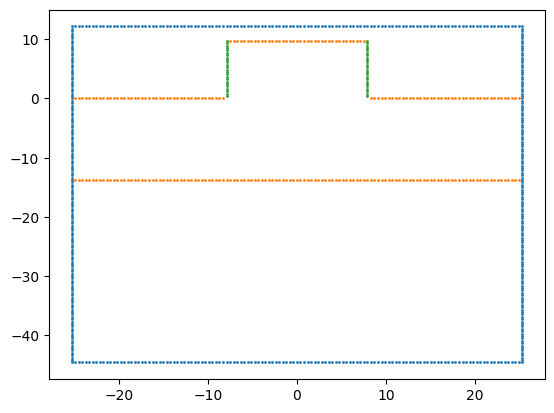

iteration 1 loss1 is 0.2655, loss2 is 0.9913, loss3 is 22.89991, loss4 is 0.0, loss5 is 0.08129, loss6 is 1.2165
3.139692544937134


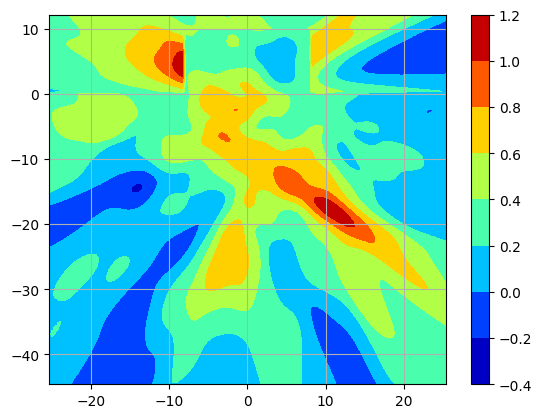

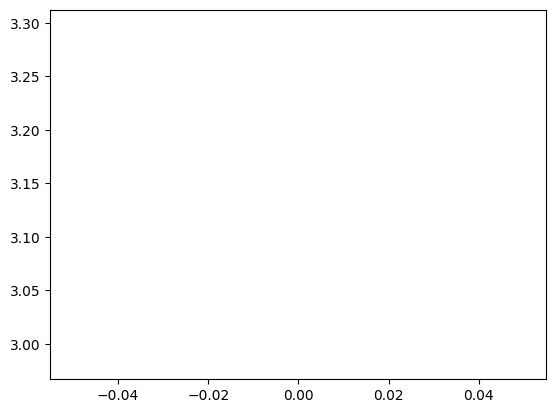

iteration 1001 loss1 is 0.04322, loss2 is 0.03944, loss3 is 0.66909, loss4 is 0.0, loss5 is 0.0137, loss6 is 0.19263
3.436237096786499


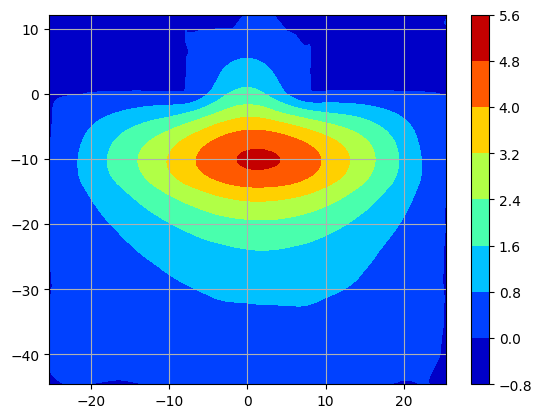

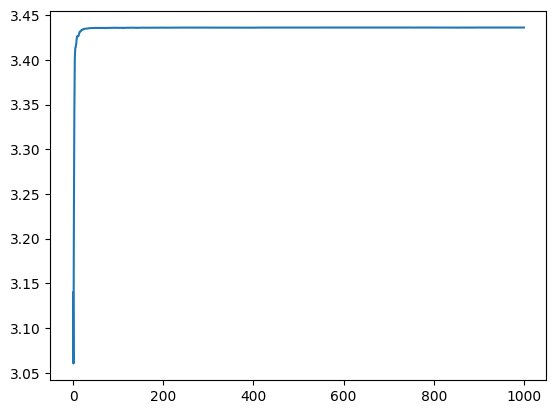

iteration 2001 loss1 is 0.04195, loss2 is 0.02279, loss3 is 0.65694, loss4 is 0.0, loss5 is 0.01419, loss6 is 0.19405
3.4363062381744385


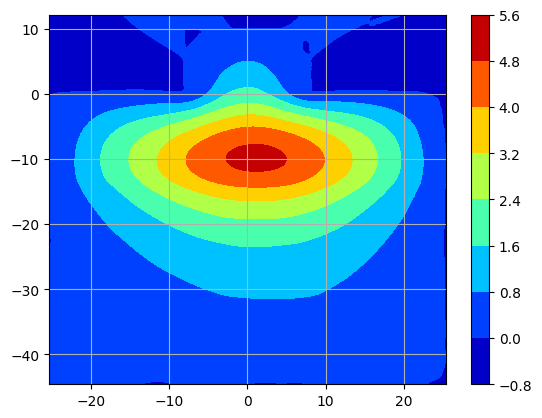

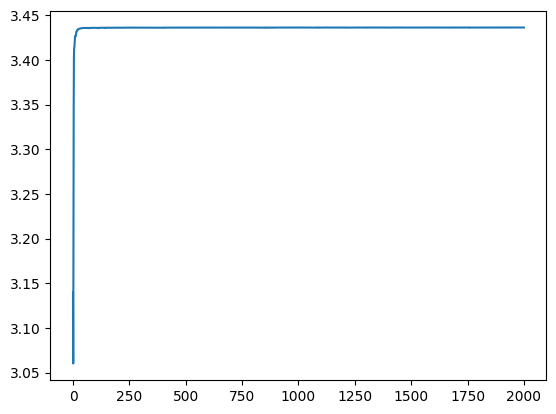

iteration 3001 loss1 is 0.04785, loss2 is 0.01796, loss3 is 0.65725, loss4 is 0.0, loss5 is 0.01818, loss6 is 0.28847
3.4363045692443848


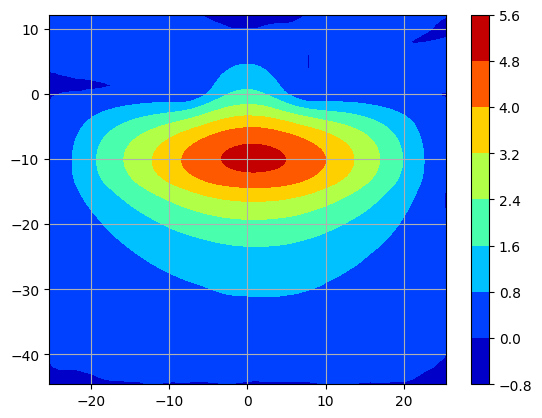

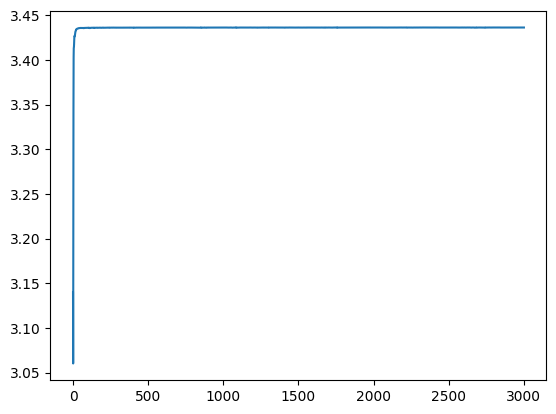

iteration 4001 loss1 is 0.01651, loss2 is 0.00558, loss3 is 0.64838, loss4 is 0.0, loss5 is 0.00418, loss6 is 0.03831
3.436356544494629


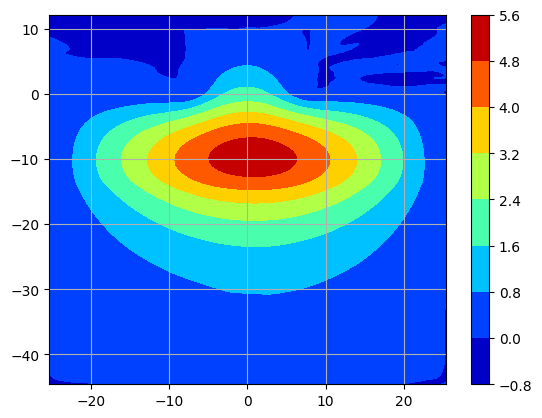

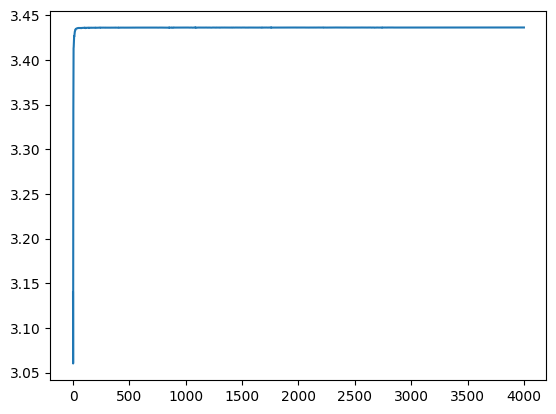

iteration 5001 loss1 is 0.01169, loss2 is 0.004, loss3 is 0.6482, loss4 is 0.0, loss5 is 0.00112, loss6 is 0.01908
3.4363577365875244


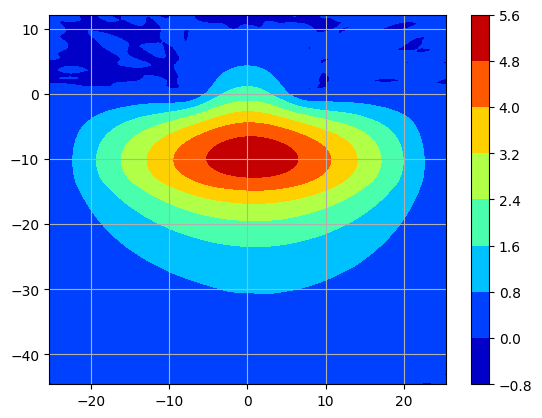

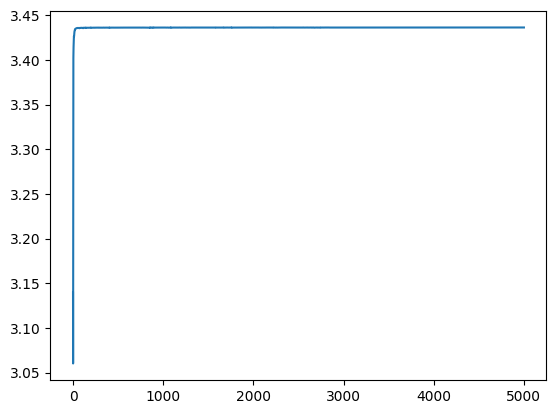

iteration 6001 loss1 is 0.01172, loss2 is 0.00325, loss3 is 0.64782, loss4 is 0.0, loss5 is 0.00112, loss6 is 0.01602
3.4363598823547363


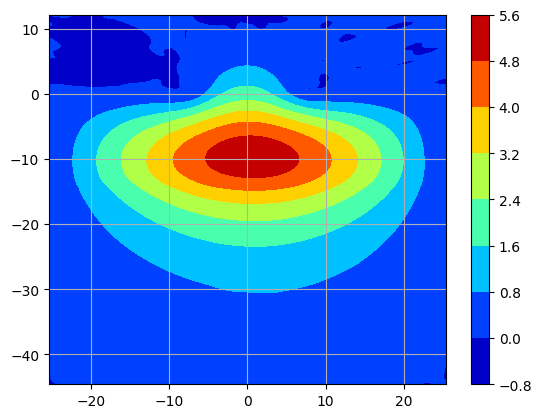

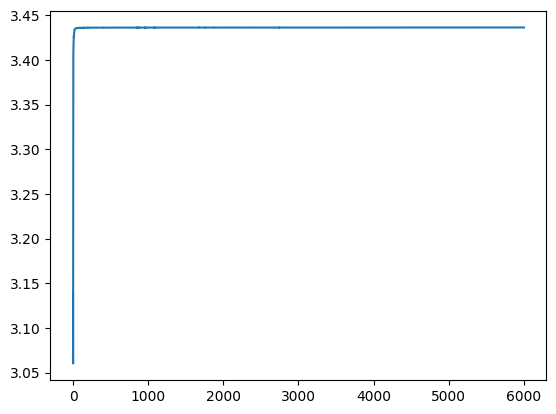

iteration 7001 loss1 is 0.01127, loss2 is 0.00282, loss3 is 0.64723, loss4 is 0.0, loss5 is 0.00097, loss6 is 0.01685
3.436363458633423


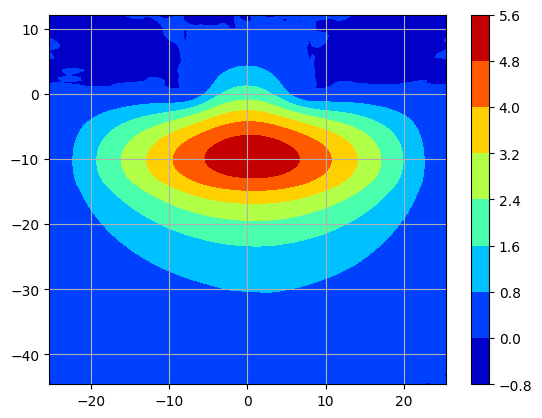

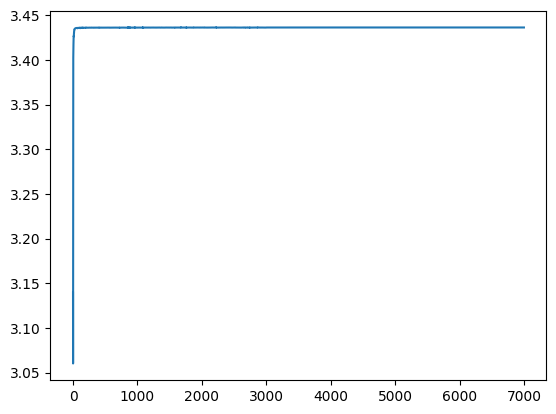

iteration 8001 loss1 is 0.01125, loss2 is 0.00258, loss3 is 0.64692, loss4 is 0.0, loss5 is 0.00094, loss6 is 0.0158
3.4363653659820557


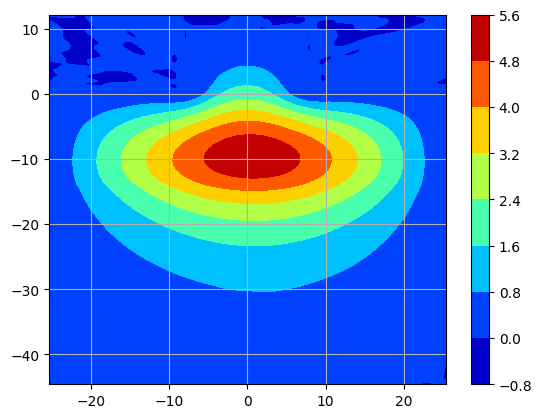

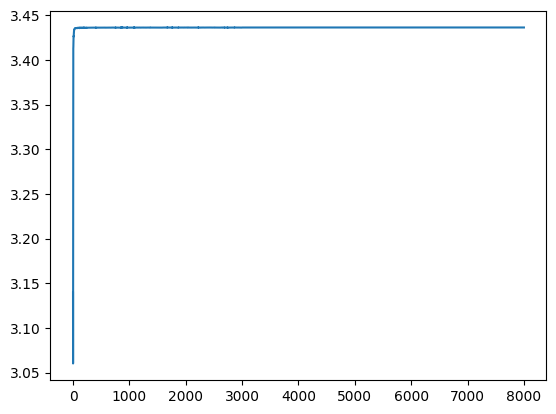

iteration 9001 loss1 is 0.0109, loss2 is 0.0023, loss3 is 0.64649, loss4 is 0.0, loss5 is 0.00086, loss6 is 0.01683
3.436367988586426


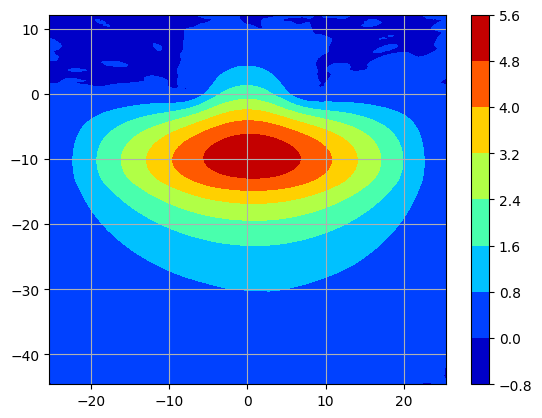

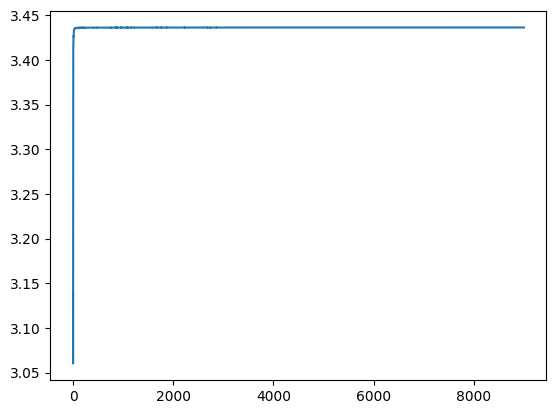

iteration 10001 loss1 is 0.01083, loss2 is 0.00209, loss3 is 0.64611, loss4 is 0.0, loss5 is 0.00088, loss6 is 0.01644
3.4363701343536377


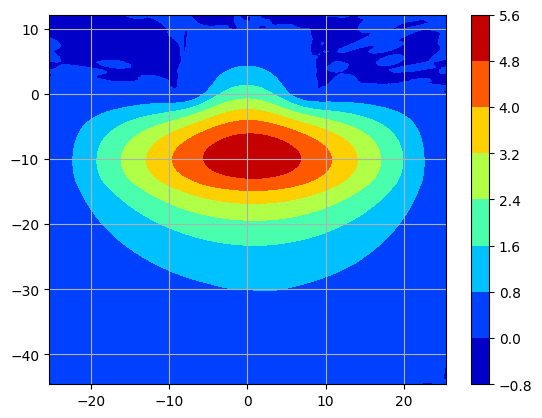

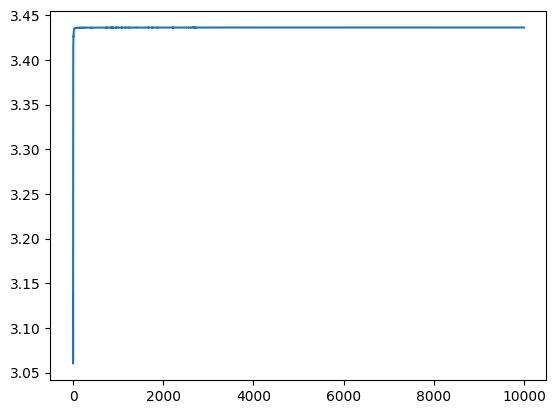

In [33]:
# loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[1, 1, 1, 1, 1, 1], verbose=1, sample_new=False)
loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[5, 1/2, 1/2, 1/2, 1, 1], verbose=1, calc_error=False, plot_solution=True, sample_new=False)

In [34]:
base_model.to('cpu')

Sequential(
  (0): Linear(in_features=3, out_features=512, bias=True)
  (1): RBF()
  (2): Linear(in_features=512, out_features=1, bias=True)
)

In [35]:
yu = torch.arange(0, reference_device.upward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yu = yu[-1]
yb = torch.arange(0, reference_device.downward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yb = yb[-1]
xy = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))

xy = torch.cat((torch.full_like(xy, 0), xy), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy, torch.square(reference_device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

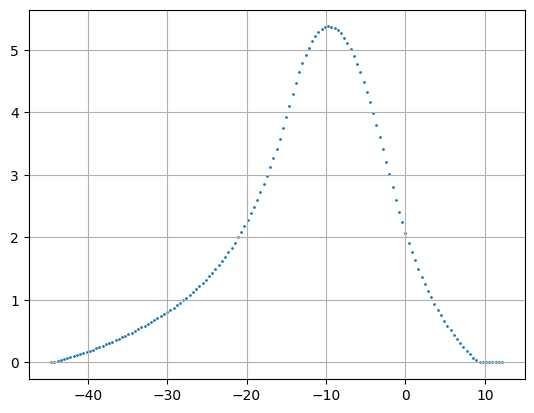

In [36]:
plt.scatter(xy[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [37]:
xy = torch.arange(-device.total_length_x/2, device.total_length_x/2, step=dx/2, device=memory_type).reshape(-1, 1)
xy = torch.cat((xy, torch.full_like(xy, 0)), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy[:], torch.square(device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

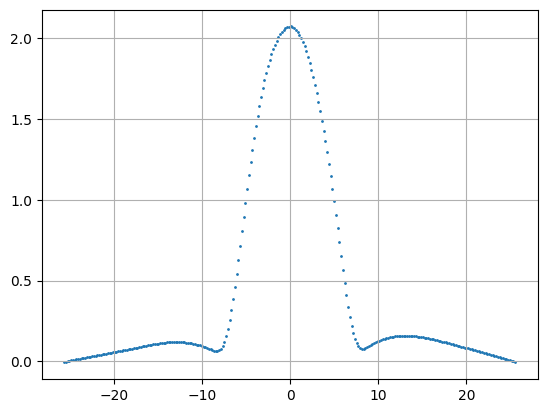

In [38]:
plt.scatter(xy[:, 0].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [39]:
study = 'TM'

In [40]:
memory_type = torch.device('cuda')
dtype = torch.float32
torch.manual_seed(42)
num_modes = 1

In [41]:
# base_model = models.discontinuity_capturing_network(2, 256, num_modes, 1, 'RBF')
base_model = models.discontinuity_capturing_network(2, 512, num_modes, 1, 'RBF')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
# optimizer = torch.optim.LBFGS(base_model.parameters(),
#                               lr=float(5e-1),
#                               max_iter=5000,
#                               max_eval=5000,
#                               history_size=300,
#                               line_search_fn="strong_wolfe",
#                               tolerance_change=10.0 * np.finfo(float).eps)
# scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[1000, 2000, 3000], gamma=0.2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[3000, 4000], gamma=0.2)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 3073


In [42]:
device = devices.RibWaveguideWithPINNs(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, base_model, True)

In [43]:
train_agent = trainers.Trainer2D(dtype, device, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=None, n_upper=None)

num samples 18189


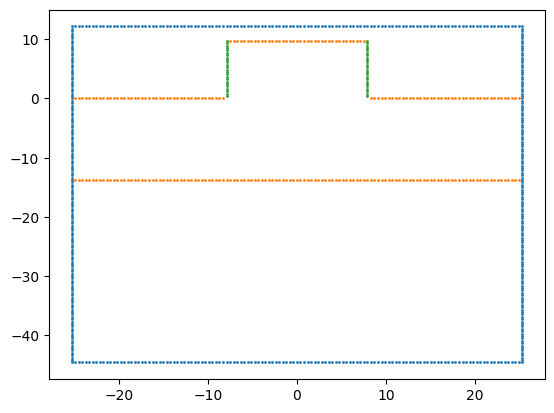

iteration 1 loss1 is 0.2655, loss2 is 0.9913, loss3 is 22.89991, loss4 is 0.0, loss5 is 0.08129, loss6 is 0.4978
3.139692544937134


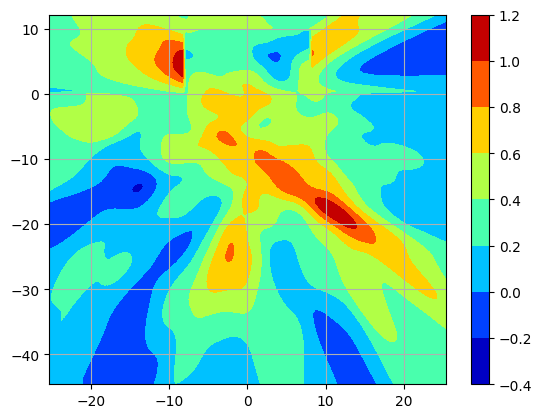

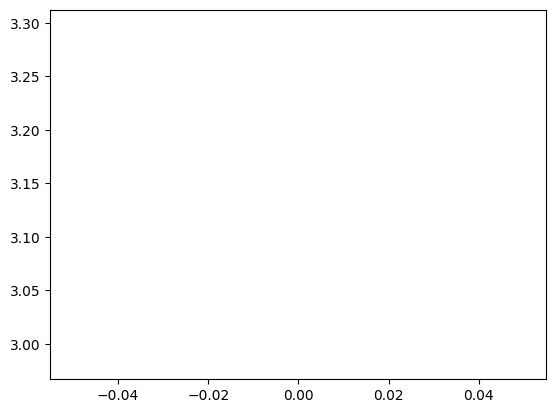

iteration 1001 loss1 is 0.04199, loss2 is 0.039, loss3 is 0.67585, loss4 is 0.0, loss5 is 0.01067, loss6 is 0.2179
3.43619966506958


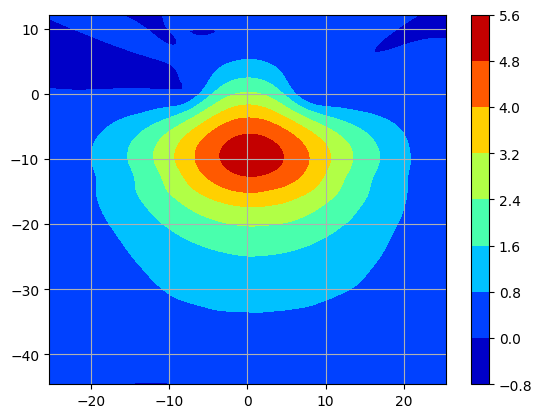

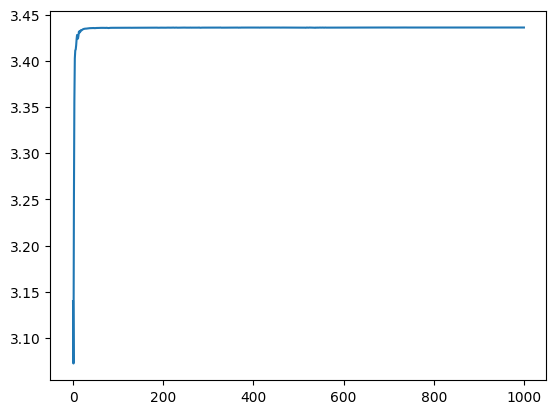

iteration 2001 loss1 is 0.03618, loss2 is 0.0289, loss3 is 0.66637, loss4 is 0.0, loss5 is 0.01315, loss6 is 0.15081
3.4362523555755615


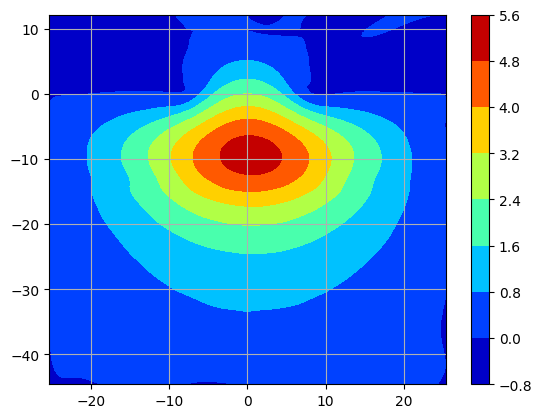

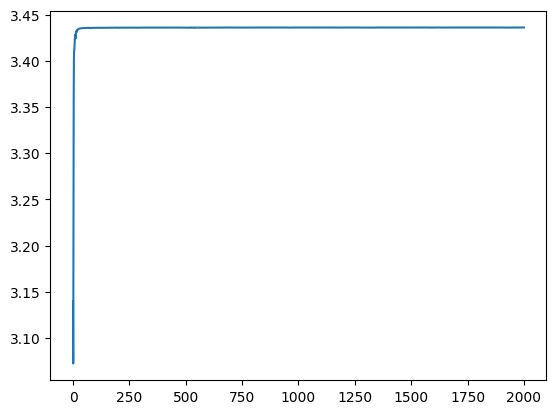

iteration 3001 loss1 is 0.03896, loss2 is 0.02121, loss3 is 0.66302, loss4 is 0.0, loss5 is 0.01595, loss6 is 0.19414
3.4362711906433105


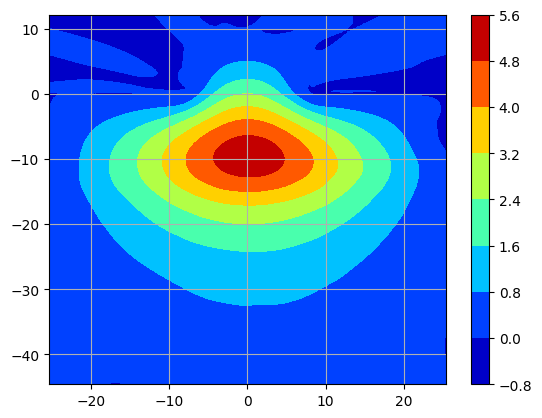

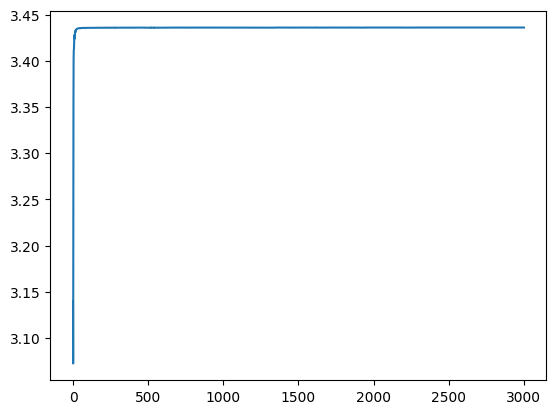

iteration 4001 loss1 is 0.0151, loss2 is 0.00379, loss3 is 0.6498, loss4 is 0.0, loss5 is 0.00263, loss6 is 0.03495
3.4363481998443604


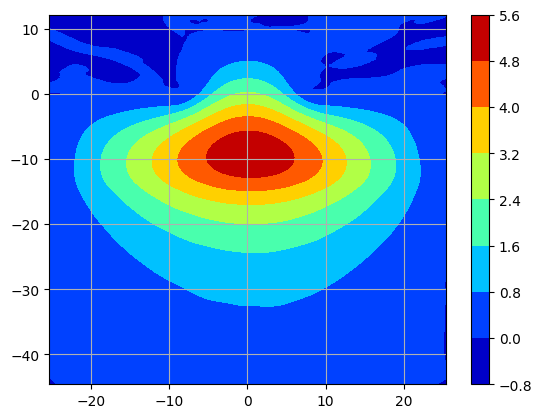

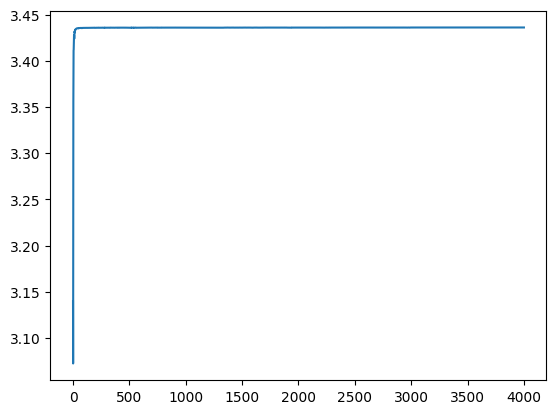

iteration 5001 loss1 is 0.01303, loss2 is 0.00265, loss3 is 0.64939, loss4 is 0.0, loss5 is 0.00128, loss6 is 0.0158
3.4363505840301514


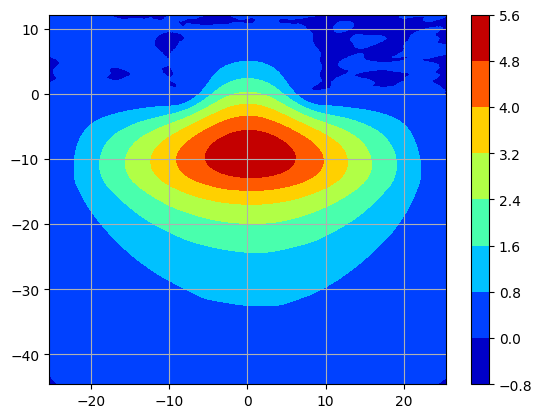

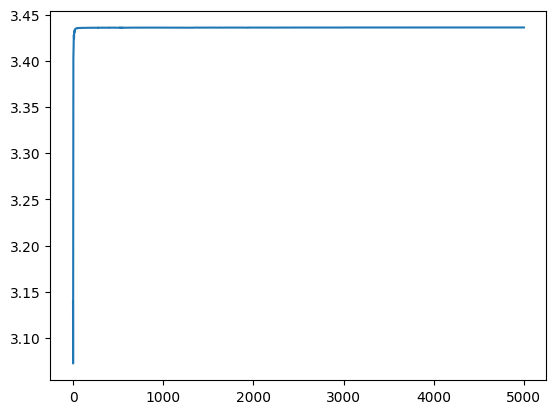

iteration 6001 loss1 is 0.01285, loss2 is 0.00221, loss3 is 0.64897, loss4 is 0.0, loss5 is 0.00109, loss6 is 0.01348
3.4363529682159424


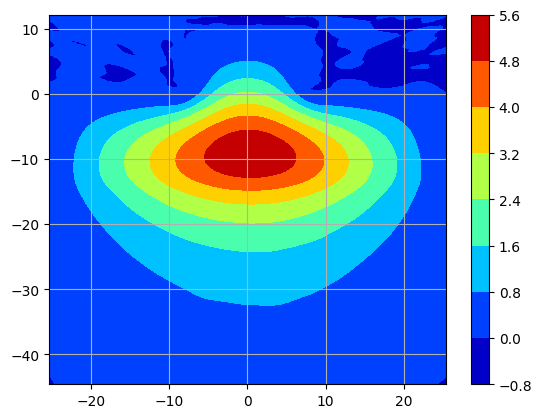

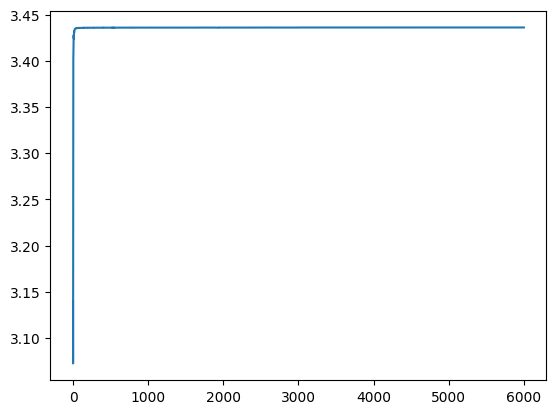

iteration 7001 loss1 is 0.01289, loss2 is 0.00199, loss3 is 0.64867, loss4 is 0.0, loss5 is 0.00115, loss6 is 0.01535
3.436354875564575


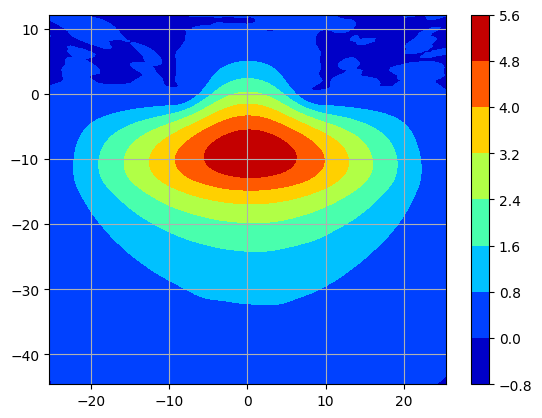

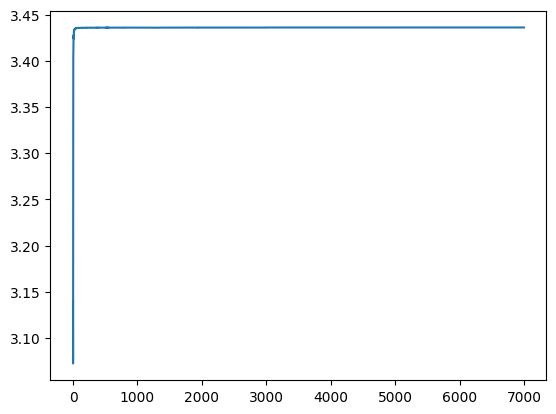

iteration 8001 loss1 is 0.01261, loss2 is 0.00189, loss3 is 0.64849, loss4 is 0.0, loss5 is 0.00105, loss6 is 0.01507
3.4363560676574707


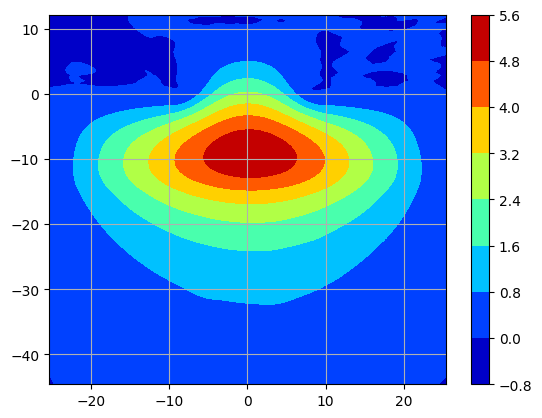

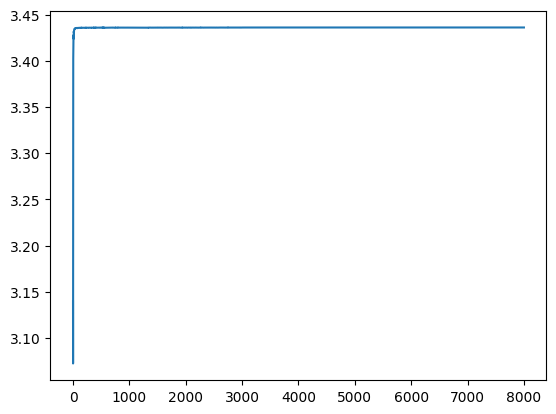

iteration 9001 loss1 is 0.0123, loss2 is 0.00176, loss3 is 0.6482, loss4 is 0.0, loss5 is 0.00104, loss6 is 0.01569
3.4363577365875244


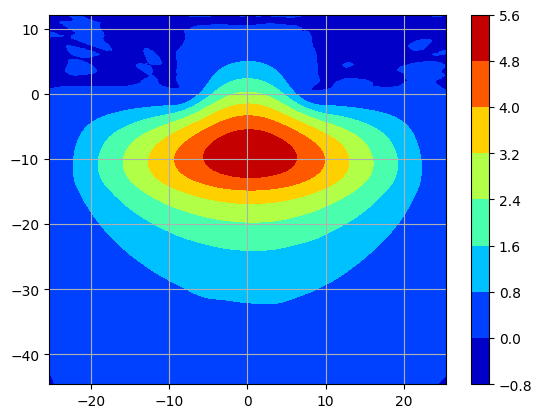

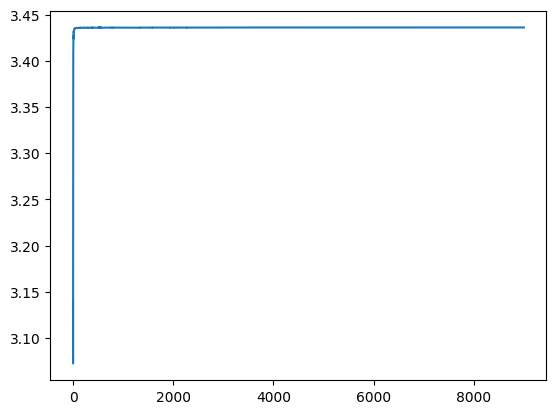

iteration 10001 loss1 is 0.01209, loss2 is 0.0017, loss3 is 0.6482, loss4 is 0.0, loss5 is 0.00105, loss6 is 0.01416
3.4363577365875244


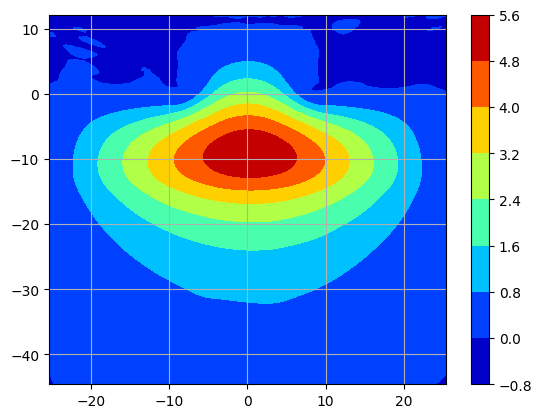

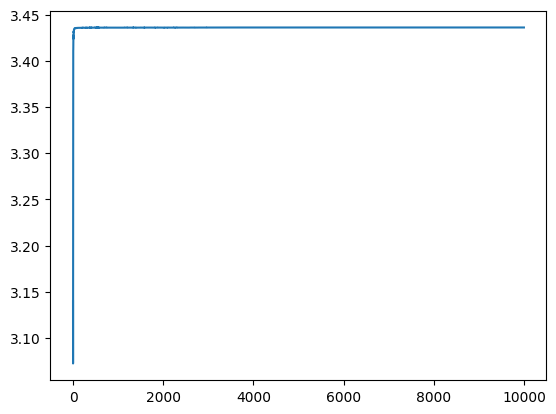

In [44]:
# loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[1, 1, 1, 1, 1, 1], verbose=1, sample_new=False)
loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[5, 1/2, 1/2, 1/2, 1, 1], verbose=1, calc_error=False, plot_solution=True, sample_new=False)

In [45]:
base_model.to('cpu')

Sequential(
  (0): Linear(in_features=3, out_features=512, bias=True)
  (1): RBF()
  (2): Linear(in_features=512, out_features=1, bias=True)
)

In [46]:
yu = torch.arange(0, reference_device.upward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yu = yu[-1]
yb = torch.arange(0, reference_device.downward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yb = yb[-1]
xy = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))

xy = torch.cat((torch.full_like(xy, 0), xy), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy, torch.square(reference_device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

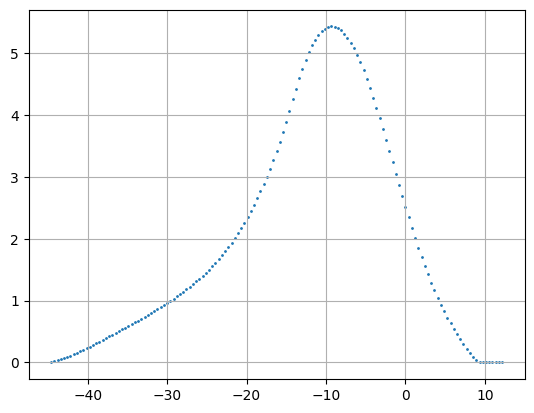

In [47]:
plt.scatter(xy[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [48]:
xy = torch.arange(-device.total_length_x/2, device.total_length_x/2, step=dx/2, device=memory_type).reshape(-1, 1)
xy = torch.cat((xy, torch.full_like(xy, 0)), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy[:], torch.square(device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

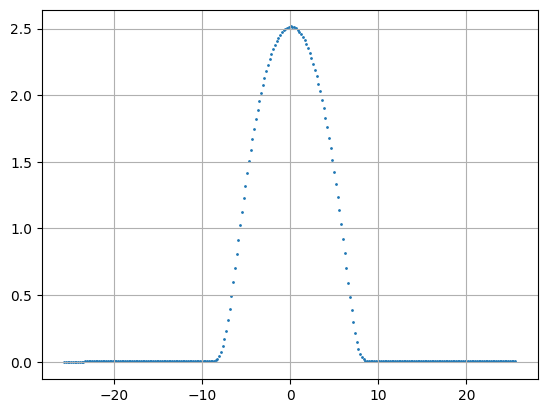

In [49]:
plt.scatter(xy[:, 0].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()